# Chronos-Bolt layer probing - structural aliasing, lean edition

One signal, generated here (named + saved), pushed through every stage. Three questions:
1. **Irreversibility** - the one-patch-shift test: at an integer cpp `x[n+P]=x[n]`, so a signal and its
   one-patch-advanced copy are identical from `patched` on (incl. the decoder output) -> the loss is
   architectural and cannot be undone.
2. **Round-trip** - does the forecast reproduce the input spectrum?
3. **Where the injected tone vanishes** - output-vs-input frequency sweep (analog of Pagani et al. Fig. 5).

Note on the decoder: Chronos-Bolt is a *direct* multi-horizon forecaster - the decoder runs once on
learned query tokens and emits the whole horizon, it is NOT autoregressive. So its analysis is the
frequency response of its **output**, plus the shift distance read at `dec_out`.

## Setup

In [9]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
np.random.seed(42); torch.manual_seed(42)
import pandas as pd

sys.path.insert(0, "../data/synthetic/")         
import signalGenerator as sg                      


pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model; cfg = model.config.chronos_config
P, S_DEF, PRED_LEN = cfg["input_patch_size"], cfg["input_patch_stride"], cfg["prediction_length"]
N_ENC, N_DEC = len(model.encoder.block), len(model.decoder.block)
print(f"P={P} S={S_DEF} pred_len={PRED_LEN} enc={N_ENC} dec={N_DEC}")

P=16 S=16 pred_len=64 enc=4 dec=4


In [10]:
OUT = Path("../outputs/signals/")
existing = [d for d in OUT.iterdir() if d.is_dir() and d.name.startswith("signal_")]
if existing:
    i = max([int(d.name.split("_")[1]) for d in existing]) + 1
else:    
    i = 0
OUT = OUT/f"signal_{i}"
OUT.mkdir(parents=True, exist_ok=True)
print(f"Saving outputs to {OUT}")

Saving outputs to ../outputs/signals/signal_8


## 1 - Generate the probe signal here (named & saved)
Edit `GEN` and `INJECT`. cpp = cycles per patch (blind spots at integer cpp); or use mode `"hz"`
(cpp = value*P/fs). The signal is saved under `../outputs/signals/<name>.npy`.

In [11]:
json_config = [
    {
        "generator": "kernelsynth",
        "n_realizations": 5,
        "seed": 12,
        "params": {
            "J": 5,
            "l_syn": 512,
            "fs": 256,
            "jitter": 1e-4,
            "P": 16,
            "inject": {
                "mode": "cpp",
                "value": 7.37,
                "amplitude": 0.05,
                "phase": 1.5707963
            }
        }
    }
]

In [12]:
if json_config[0]["generator"] == "kernelsynth":
    gen = sg.runKernelSynth(json_config[0]["params"], json_config[0]["seed"])
    NAME = "kernelsynth"
else:
    gen = sg.runTSMixup(json_config[0]["params"], json_config[0]["seed"])
    NAME = "tsmixup"

print(gen.getParameters())

{'generator': 'KernelSynth', 'J': 5, 'l_syn': 512, 'fs': 256, 'jitter': 0.0001, 'inject': {'mode': 'cpp', 'value': 7.37, 'amplitude': 0.05, 'phase': 1.5707963}}


In [13]:
signal = np.asarray(gen.generate(), float).ravel()
gen.save(signal)
ctx = signal[:512]

inject = json_config[0]["params"]["inject"]
INJECT = {
    "mode": inject["mode"],
    "value": inject["value"] if inject["mode"] == "cpp" else inject["value"] * P / 256,
    "amplitude": inject["amplitude"],
    "phase": inject["phase"]
}


In [14]:
cpp = INJECT["value"] if INJECT["mode"] == "cpp" else INJECT["value"] * P / FS
cls = "BLIND (on grid)" if abs(cpp - round(cpp)) < 1e-6 and 1 <= round(cpp) <= P // 2 else "off-grid / safe"
print(f"saved {gen.path()}  |  cpp={cpp:.3f}  [{cls}]")

saved /Users/federicosabbadini/Library/Mobile Documents/com~apple~CloudDocs/Workspaces/gitHub-workspace/patchAliasing/chronos/data/synthetic/signals/KernelSynth_J5_l_syn512_fs256_jitter0.0001__cpp7.37_amp0.05_ph1.5708.txt  |  cpp=7.370  [off-grid / safe]


In [15]:
# make a summary of all parameters in DataFrame for later analysis
params = gen.getParameters()
df = pd.DataFrame([params])
for k, v in params.items():
    if k == 'inject':
        for ik, iv in v.items():
            df[f"{ik}"] = iv
    else:
        df[f"{k}"] = v
df.drop(columns=["inject"], inplace=True) # flatten inject dict into columns

df

,generator,J,l_syn,fs,jitter,mode,value,amplitude,phase
0,KernelSynth,5,512,256,0.0001,cpp,7.37,0.05,1.570796


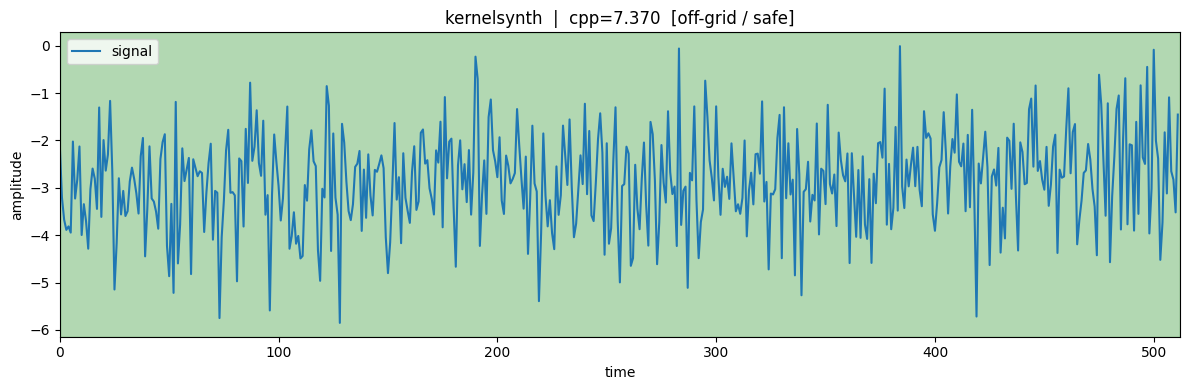

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(signal, label="signal")
plt.axvspan(0, 512, color="green", alpha=0.3)
plt.title(f"{NAME}  |  cpp={cpp:.3f}  [{cls}]")
plt.xlabel("time"); plt.ylabel("amplitude"); plt.legend();
plt.xlim(0, len(signal));
plt.tight_layout(); plt.savefig(OUT/f"{NAME}.png") 
plt.show() 

## 2 - Capture every stage

In [17]:
def cut(x, P, S): return np.stack([x[i:i+P] for i in range(0, len(x)-P+1, S)])
def as_matrix(t):
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy(); return a[0] if a.ndim == 3 else a

def forward_capture(context, stride=S_DEF):
    cap, handles = {}, []
    model.patch.patch_stride = stride
    def save(key, use_in=False):
        def hook(m, i, o): cap[key] = as_matrix(i[0] if use_in else o)
        return hook
    if hasattr(model, "instance_norm"): handles.append(model.instance_norm.register_forward_hook(save("scaled")))
    handles.append(model.patch.register_forward_hook(save("patched")))
    handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
    handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
    for k, b in enumerate(model.encoder.block): handles.append(b.register_forward_hook(save(f"enc{k}")))
    for k, b in enumerate(model.decoder.block): handles.append(b.register_forward_hook(save(f"dec{k}")))
    if hasattr(model, "output_patch_embedding"): handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))
    x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
    with torch.no_grad(): fc = pipeline.predict(x, prediction_length=PRED_LEN)
    for h in handles: h.remove()
    model.patch.patch_stride = S_DEF
    sc = cap.pop("scaled", None)
    cap = {"input": cut(context, P, stride),
           "scaled": cut(np.asarray(sc).ravel(), P, stride) if sc is not None else cut(context, P, stride), **cap}
    return fc, cap

forecast, cap = forward_capture(ctx)
STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
STAGES = [s for s in STAGES if s in cap]
print("captured:", len(STAGES), "stages")

captured: 14 stages


## 3 - Irreversibility: one-patch-shift test (+ blind-spot sweep, incl. decoder)
Run on the **pure tone** (no background), because only a purely periodic signal makes the test exact:
`roll(pure, P)` equals `pure` at integer cpp, so the distance is 0 at every stage. Left: per-stage for
the chosen cpp vs an off-grid control. Right: the distance at `patched` and `dec_out` swept over cpp -
zeros exactly on the blind spots, and the decoder output inherits them (it cannot recover what the
tokeniser merged).

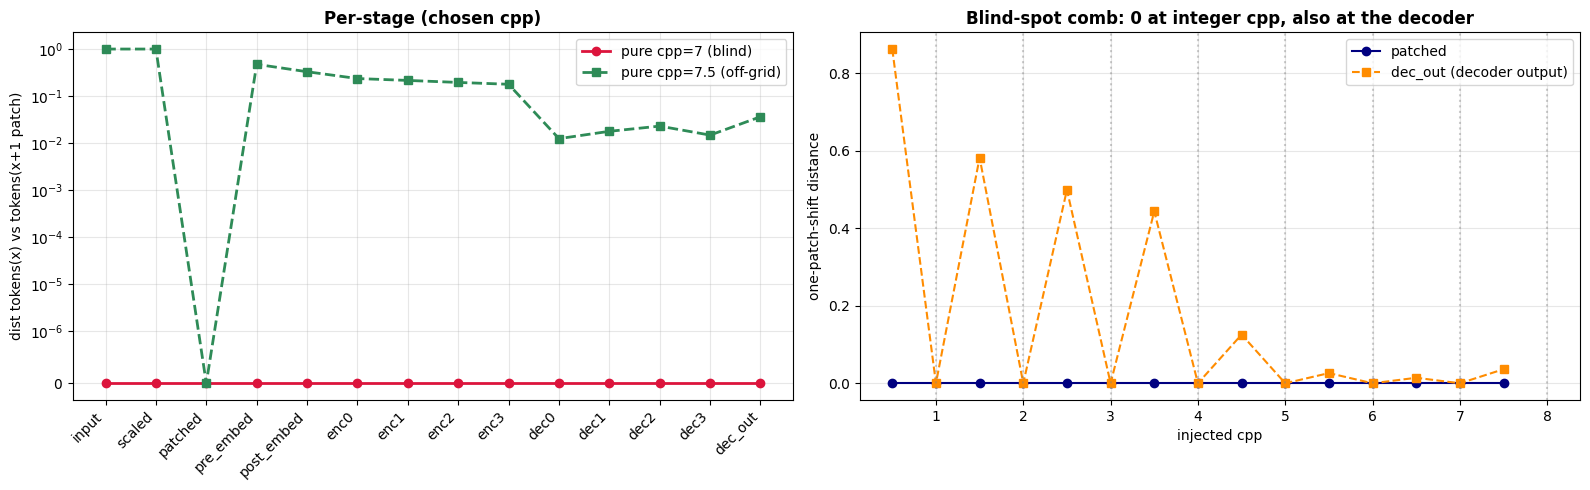

In [18]:
def stage_dist(a, b):
    m = min(len(a), len(b)); a, b = np.asarray(a[:m], float), np.asarray(b[:m], float)
    return float(np.abs(a-b).mean() / (np.abs(a).mean() + np.abs(b).mean() + 1e-9))
def pure(c, L=512): n = np.arange(L); return np.sin(2*np.pi*c*n/P)

cb = round(cpp) if (1 <= round(cpp) <= P//2) else 2
_, A  = forward_capture(pure(cb));     _, As = forward_capture(np.roll(pure(cb), P))
_, B  = forward_capture(pure(cb+0.5)); _, Bs = forward_capture(np.roll(pure(cb+0.5), P))
D_blind = [stage_dist(A[s], As[s]) for s in STAGES]
D_off   = [stage_dist(B[s], Bs[s]) for s in STAGES]

CPPS = np.round(np.arange(0.5, 7.51, 0.5), 2)
d_patched, d_decout = [], []
for c in CPPS:
    _, c1 = forward_capture(pure(c)); _, c2 = forward_capture(np.roll(pure(c), P))
    d_patched.append(stage_dist(c1["patched"], c2["patched"]))
    d_decout.append(stage_dist(c1["dec_out"], c2["dec_out"]))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(16, 5)); xs = np.arange(len(STAGES))
a0.plot(xs, D_blind, "o-", color="crimson",  lw=2, label=f"pure cpp={cb} (blind)")
a0.plot(xs, D_off,   "s--", color="seagreen", lw=2, label=f"pure cpp={cb+0.5} (off-grid)")
a0.set_yscale("symlog", linthresh=1e-6); a0.set_xticks(xs); a0.set_xticklabels(STAGES, rotation=45, ha="right")
a0.set_ylabel("dist tokens(x) vs tokens(x+1 patch)"); a0.set_title("Per-stage (chosen cpp)", fontweight="bold")
a0.legend(); a0.grid(alpha=.3)
a1.plot(CPPS, d_patched, "o-", color="navy", label="patched")
a1.plot(CPPS, d_decout, "s--", color="darkorange", label="dec_out (decoder output)")
for k in range(1, P//2+1): a1.axvline(k, color="grey", ls=":", alpha=.4)
a1.set_xlabel("injected cpp"); a1.set_ylabel("one-patch-shift distance")
a1.set_title("Blind-spot comb: 0 at integer cpp, also at the decoder", fontweight="bold")
a1.legend(); a1.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"L1_shift_irreversibility.png", dpi=140, bbox_inches="tight"); plt.show()

## 4 - Round-trip: input vs forecast spectrum

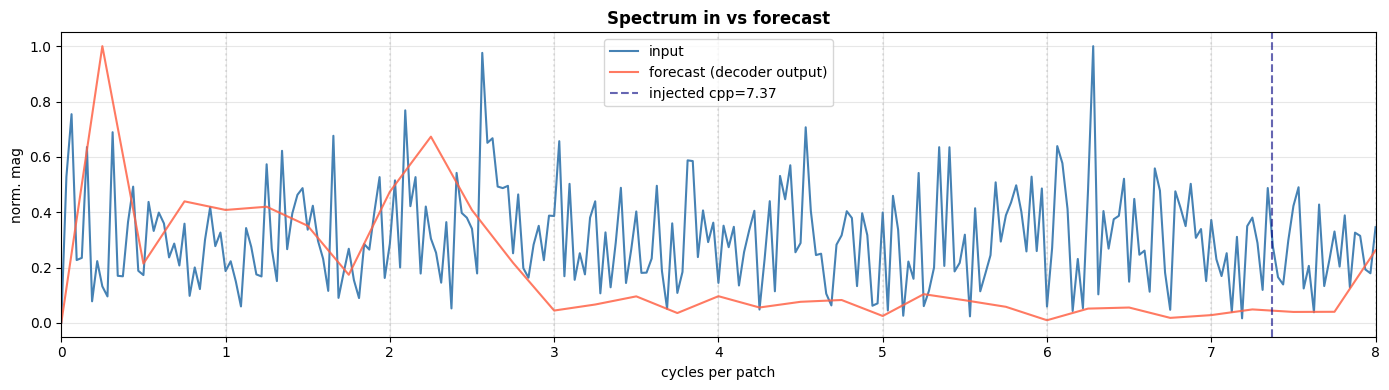

In [19]:
pred = forecast[0].median(dim=0).values.numpy()
def spec(x):
    x = np.asarray(x, float)-np.mean(x); m = np.abs(np.fft.rfft(x)); return np.fft.rfftfreq(len(x))*P, m
cin, mi = spec(ctx); cout, mo = spec(pred)
plt.figure(figsize=(14, 4))
plt.plot(cin, mi/(mi.max()+1e-9), color="steelblue", label="input")
plt.plot(cout, mo/(mo.max()+1e-9), color="tomato", alpha=.85, label="forecast (decoder output)")
plt.axvline(cpp, color="navy", ls="--", alpha=.6, label=f"injected cpp={cpp:.2f}")
for k in range(1, P//2+1): plt.axvline(k, color="grey", ls=":", alpha=.2)
plt.xlim(0, P/2); plt.xlabel("cycles per patch"); plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast", fontweight="bold"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/"L1_roundtrip.png", dpi=140, bbox_inches="tight"); plt.show()

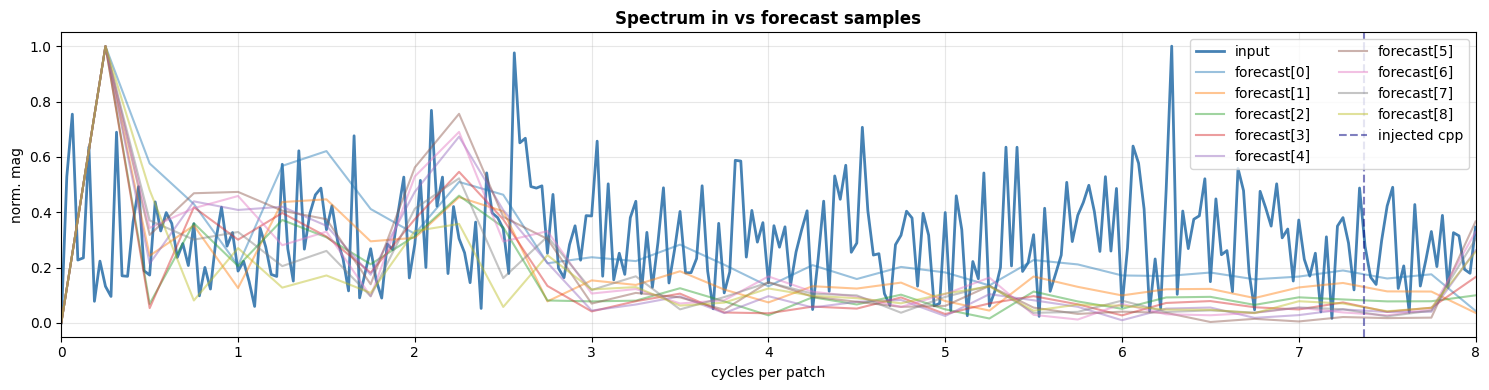

In [20]:
preds = [forecast[0][i].numpy() for i in range(9)]

def spec(x):
    x = np.asarray(x, float) - np.mean(x)
    m = np.abs(np.fft.rfft(x))
    return np.fft.rfftfreq(len(x)) * P, m

cin, mi = spec(ctx)

plt.figure(figsize=(15, 4))
plt.plot(cin, mi / (mi.max() + 1e-9), color="steelblue", lw=2, label="input")

for i, pred in enumerate(preds):
    cout, mo = spec(pred)
    plt.plot(cout, mo / (mo.max() + 1e-9), alpha=0.45, label=f"forecast[{i}]")

if cpp:
    plt.axvline(cpp, color="navy", ls="--", alpha=0.5, label="injected cpp")

plt.xlim(0, P / 2)
plt.xlabel("cycles per patch")
plt.ylabel("norm. mag")
plt.title("Spectrum in vs forecast samples", fontweight="bold")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "L1_roundtrip_samples.png", dpi=140, bbox_inches="tight")
plt.show()




In [21]:
print("pred std:", np.std(pred))
print("pred min:", pred.min())
print("pred max:", pred.max())
print("pred first values:", pred[:20])

pred std: 0.04367966
pred min: -1.3991845
pred max: -1.1793694
pred first values: [-1.3991845 -1.3040986 -1.2741251 -1.274497  -1.3074999 -1.3103979
 -1.3278997 -1.3170241 -1.3135747 -1.3055408 -1.3079423 -1.280279
 -1.2724699 -1.2557544 -1.2481685 -1.2517594 -1.2855594 -1.2735579
 -1.2854327 -1.2580955]
